In [180]:
import pandas as pd 
import numpy as np

In [181]:
df = pd.read_csv("powerplant_data.csv")

In [182]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


# I/P
# AT => Temperature
# V => Vaccum
# AP => Pressure
# RH => Humidity

# O/P
# PE => produced energy 

In [183]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [184]:
X = df.drop("PE",axis=1)
y = df["PE"]

In [185]:
# Split Out Data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [186]:
df.shape

(9568, 5)

In [187]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [188]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled,dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled,dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [189]:
from torch.utils.data import TensorDataset,DataLoader
train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

In [190]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32)

## Deep Learning

In [191]:
# Define Our ANN Model
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
    
        self.model = nn.Sequential(
            # 1st Hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),
            
            # 2nd Hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),
            
            # Output Layer
            nn.Linear(6, 1),
        )
        
    def forward(self, x):
        return self.model(x)

In [192]:
import torch.optim as optim
model = ANN()
# loss func , optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [193]:
# Training Our Model
training_losses=[]
validation_losses=[]

best_val_loss = float("inf")
epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 #total training loss for 1 epoch

    for xb,yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()
        
        outputs = model(xb) #forward propagation..... predicted output for this batch
        loss = crietrion(outputs,yb) #compute loss
        loss.backward() #backward prop...gradient compute
        optimizer.step() # Parameters update

        running_loss += loss.item() #loss is a tensor convert to python float value

    epoch_train_loss = running_loss/len(train_loader)
    training_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): #no gradient compute
         for xb,yb in test_loader:
             outputs = model(xb) 
             loss = crietrion(outputs,yb)
             running_val_loss += loss.item()
        
    epoch_val_loss = running_val_loss/len(test_loader)
    validation_losses.append(epoch_val_loss)    

    print(f"epoch {epoch+1}/{epochs} ==> training loss = {epoch_train_loss} & validation loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss;
        torch.save(model.state_dict(),"best_model.pt") #.pt or .pth

epoch 1/100 ==> training loss = 205931.187890625 & validation loss = 204646.36901041667
epoch 2/100 ==> training loss = 201104.67649739582 & validation loss = 193717.60859375
epoch 3/100 ==> training loss = 175360.68033854166 & validation loss = 151197.05520833333
epoch 4/100 ==> training loss = 119872.44186197917 & validation loss = 88536.0765625
epoch 5/100 ==> training loss = 62663.6123046875 & validation loss = 42250.805078125
epoch 6/100 ==> training loss = 31459.70380045573 & validation loss = 24435.849267578124
epoch 7/100 ==> training loss = 21336.064607747398 & validation loss = 18723.236214192708
epoch 8/100 ==> training loss = 17121.501049804687 & validation loss = 15263.911669921876
epoch 9/100 ==> training loss = 13860.15517171224 & validation loss = 12165.618806966146
epoch 10/100 ==> training loss = 10844.978214518229 & validation loss = 9331.12568359375
epoch 11/100 ==> training loss = 8134.026432291666 & validation loss = 6842.4516194661455
epoch 12/100 ==> training lo

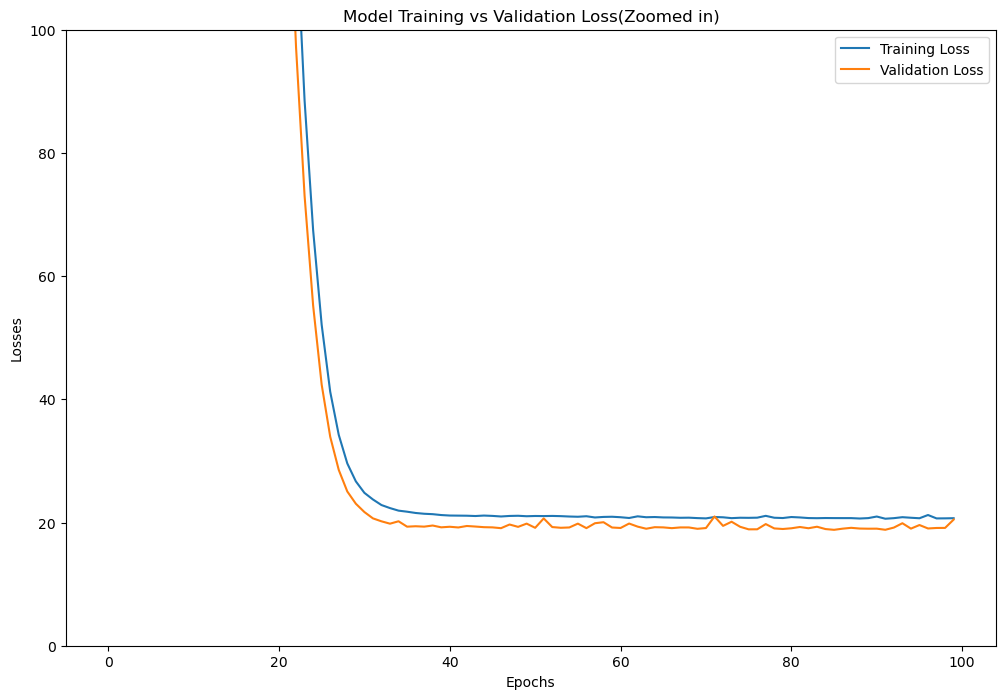

In [194]:
import matplotlib.pyplot as plt
loss_df= pd.DataFrame({
    "Training Loss" : training_losses,
    "Validation Loss"   : validation_losses
})

plt.figure(figsize=(12,8))
plt.plot(loss_df["Training Loss"],label="Training Loss")
plt.plot(loss_df["Validation Loss"],label="Validation Loss")
plt.title("Model Training vs Validation Loss(Zoomed in)")
plt.ylim(0,100)
plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()

In [195]:
# Loading best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [196]:
# Evaluate Our Model
model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = crietrion(train_preds,y_train_tensor)
    test_mse_loss = crietrion(test_preds,y_test_tensor)


print("Training MSE:",train_mse_loss.item())
print("Testing MSE:",test_mse_loss.item())

Training MSE: 20.478540420532227
Testing MSE: 18.82025146484375


In [197]:
from sklearn.metrics import r2_score

print("r^2 score =",r2_score(y_test,test_preds))

r^2 score = 0.9342280832119559


In [198]:
predicted_df = pd.DataFrame(test_preds.numpy(),columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values,columns=["Actual Values"])

pd.concat([predicted_df,actual_df],axis=1)

,Predicted Values,Actual Values
0,434.960510,433.27
1,436.882050,438.16
2,461.729889,458.42
3,476.781647,480.82
4,435.632690,441.41
...,...,...
1909,451.118622,456.70
1910,431.449585,438.04
1911,467.523529,467.80
1912,430.980133,437.14
